In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

import pandas as pd
import sys
import re

import_path = Path.cwd().parents[1]
sys.path.insert(0, str(import_path))
import feature_utils as futils

In [13]:
root_dir = Path(r"E:\segs_clust_7754")
pc_dir = Path(root_dir / "pc_1024")
k_dir = Path(pc_dir / "k_08")

local_feature_root = Path(r"D:\logmel_outputs_9979")
cfg = np.load(root_dir / "config_and_ipca.npz")

Z2 = np.load(pc_dir / "pca2_scores.npy")
labels = np.load(k_dir / "segment_labels.npy")
centers = np.load(k_dir / "kmeans_centers.npy")

print(Z2.shape)
print(labels.shape)

k = 8

(631898, 2)
(631898,)


In [14]:
with np.load(pc_dir.parent / "config_and_ipca.npz") as data:
    print(data["downsample_target"])
    for key in data.files:
        print(f"{key}")

150
ipca_components
ipca_mean
scaler_mean
scaler_scale
explained_variance
explained_variance_ratio
segment_sec
clip_sec
mels_start
mels_end
downsample_target
n_mels
n_components


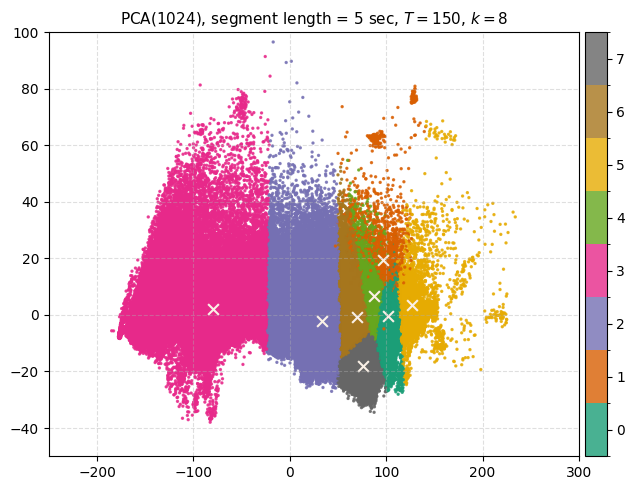

In [15]:
plt.figure(figsize=(7, 5))
fig = plt.gcf()
cmap = plt.get_cmap("Dark2", k)
norm = mcolors.BoundaryNorm(np.arange(-0.5, k + 0.5, 1), cmap.N)
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=2, cmap=cmap, norm=norm, alpha=0.8)
plt.scatter(centers[:, 0], centers[:, 1], c="linen", s=60, marker="x", label="Centroids")
plt.title("PCA(1024), segment length = 5 sec, $T = 150$, $k = 8$", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
ax = plt.gca()
ax.set_ylim(-50, 100)
ax.set_xlim(-250, 300)
colorbar = plt.colorbar(sc, ticks=np.arange(k), pad=0.01)
plt.tight_layout()
report_save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures\pca_kmeans_clusters")
plt.savefig(report_save_path / "pca2_kmeans_8clusters_fullset_segs5s_downT150_2.png", dpi=300)
plt.show()

In [16]:
segment_sec = float(cfg["segment_sec"])
clip_sec = float(cfg["clip_sec"])
mels_start = int(cfg["mels_start"])
mels_end = int(cfg["mels_end"])
downsample_T = int(cfg["downsample_target"])

print("segment_sec =", segment_sec)
print("clip_sec    =", clip_sec)
print("mels range  =", mels_start, ":", mels_end)
print("downsample_T=", downsample_T)

def load_segment_spectrogram(local_feature_root, file_path_str, seg_idx):
    remote_path = Path(file_path_str)
    marker = "extraction_uwref"
    if marker not in remote_path.parts:
        raise ValueError(f"Expected '{marker}' in path: {file_path_str}")
    
    i = remote_path.parts.index(marker)
    rel = Path(*remote_path.parts[i + 1 :])  # Path relative to second_extraction.
    npz_path = local_feature_root / rel

    with np.load(npz_path) as z:
        s = np.squeeze(z["feature"])  # (n_mels, T_full) or (1, n_mels, T_full).
    if s.ndim != 2:
        return None
    
    s = s[mels_start:mels_end, :] # (M, T_full)
    M, T = s.shape
    if T <= 0 or M <= 0:
        return None

    frames_per_segment = int(round(T * (segment_sec / clip_sec)))
    if frames_per_segment <= 0:
        return None

    start = seg_idx * frames_per_segment
    end = start + frames_per_segment
    if end > T:
        return None

    seg = s[:, start:end]  # (M, frames_per_segment)

    # Downsample in time exactly as in the clustering pipeline.
    seg_ds = futils.downsample_time_avgpool_from_db(seg, T_target=downsample_T, ref=1.0).numpy()

    return seg_ds, npz_path, (start, end, T)

def parse_feature_segment(s: str):
    # "/home/.../file.npz#seg15" -> ("/home/.../file.npz", 15)
    path_str, frag = s.split("#", 1)
    m = re.fullmatch(r"seg(\d+)", frag.strip())
    if not m:
        raise ValueError(f"Bad segment fragment '{frag}' in: {s}")
    return path_str, int(m.group(1))

def slurm_to_local_npz(slurm_path_str: str, local_feature_root: str, marker="extraction_uwref") -> Path:
    p = Path(slurm_path_str)
    parts = p.parts
    if marker not in parts:
        raise ValueError(f"Expected '{marker}' in path: {slurm_path_str}")
    i = parts.index(marker)
    rel = Path(*parts[i+1:])  # e.g. Aug_6229/6229....npz
    return Path(local_feature_root) / rel

def load_segment_spectrogram_from_local(npz_path_str, seg_idx,
                                        mels_start, mels_end,
                                        segment_sec, clip_sec, downsample_T):
    npz_path = Path(npz_path_str)
    with np.load(npz_path, mmap_mode="r") as z:
        s = np.squeeze(z["feature"])
    if s.ndim == 3:
        s = s[0]
    if s.ndim != 2:
        return None

    s = s[mels_start:mels_end, :]
    M, T = s.shape
    frames_per_segment = int(round(T * (segment_sec / clip_sec)))
    if frames_per_segment <= 0:
        return None

    start = int(seg_idx) * frames_per_segment
    end = start + frames_per_segment
    if start < 0 or end > T:
        return None

    seg = s[:, start:end]
    seg_ds = futils.downsample_time_avgpool_from_db(seg, T_target=downsample_T, ref=1.0).numpy()
    return seg_ds, (start, end, T)

def plot_topk_from_df_nearest(df_nearest, k=10, ncols=4):
    rows = df_nearest.head(k)
    kept = []
    for _, r in rows.iterrows():
        out = load_segment_spectrogram_from_local(
            r["npz_local"], int(r["seg_idx"]),
            mels_start, mels_end, segment_sec, clip_sec, downsample_T
        )
        if out is None:
            continue
        seg_ds, (start, end, T) = out
        kept.append((r, seg_ds, start, end, T))

    n = len(kept)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3.0 * nrows),
        squeeze=False
    )
    ax_flat = axes.ravel()

    im = None
    for j, (r, seg_ds, start, end, T) in enumerate(kept):
        ax = ax_flat[j]
        im = ax.imshow(seg_ds, origin="lower", aspect="auto")
        ax.set_title(f"C={int(r['cluster'])} rank={int(r['rank'])} d2={r['dist2']:.3g}", fontsize=9)
        if j % ncols == 0:
            ax.set_ylabel("mel bin")
        else:
            ax.set_yticks([])

        ax.text(
            0.02, 0.02,
            f"{Path(r['npz_local']).name}\nseg{int(r['seg_idx'])} [{start},{end})/T={T}",
            transform=ax.transAxes, va="bottom", ha="left", fontsize=7,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
        )

    for j in range(n, nrows * ncols):
        ax_flat[j].axis("off")

    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="dB")
    plt.show()

segment_sec = 5.0
clip_sec    = 265.0
mels range  = 9 : 60
downsample_T= 150


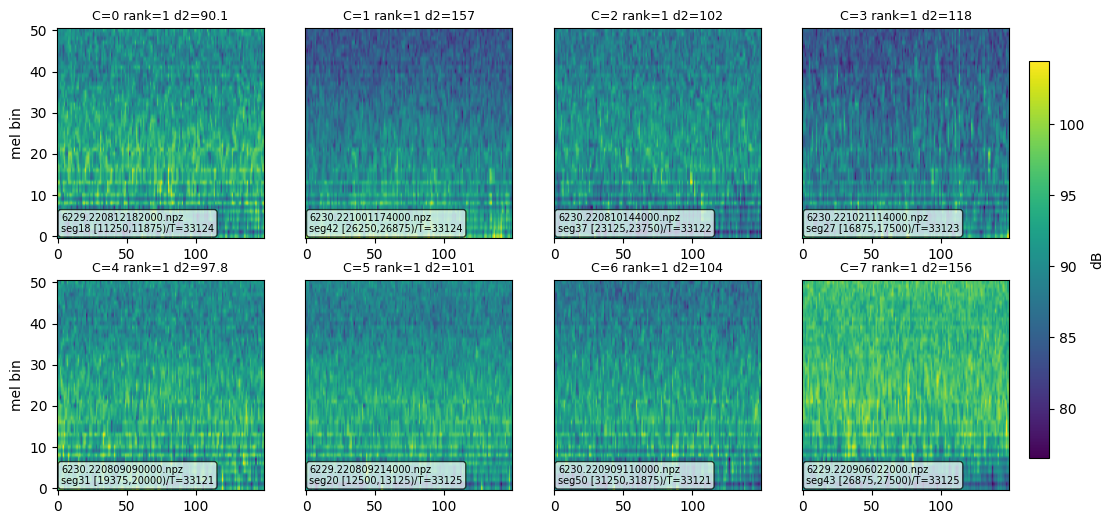

In [17]:
df_nearest = pd.read_csv(k_dir / "nearest_segments.csv")
df_nearest["slurm_npz"] = df_nearest["feature_segment"].apply(lambda s: parse_feature_segment(s)[0])
df_nearest["seg_idx"] = df_nearest["feature_segment"].apply(lambda s: parse_feature_segment(s)[1])
df_nearest["npz_local"] = df_nearest["slurm_npz"].apply(lambda p: str(slurm_to_local_npz(p, local_feature_root)))
df_nearest = df_nearest.sort_values(["rank", "cluster"])
# df_plot = df_nearest[df_nearest.index.isin([0, 500, 1000, 1500, 2000, 2501, 2788, 3288])]
plot_topk_from_df_nearest(df_nearest, k=8)